# 03 | Client decisions and resilience

Four comparisons turn the financial plan into an advisory conversation: retirement timing, a spending response to a downturn, Social Security claiming, and care plus survivor needs. Every dollar amount in a scenario is an explicit illustration, not a prediction. The comparisons share a 5% nominal annual return and 2.5% inflation unless the same one-year 2036 downturn is imposed on both choices in the spending comparison. No success probability is claimed.

**Read the endpoint correctly:** 2066 is Elena's modeled age 95 and Marco's age 93. In the survivor case Elena dies in 2051, so the 2066 balance belongs to Marco's remaining household, not to Elena.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
from dataclasses import replace
import pandas as pd
import matplotlib.pyplot as plt
from financial_plan import Assumptions, project, summary

a = Assumptions()
def frame(assumptions=a, shock=False):
    return pd.DataFrame(project(assumptions, shock_year=2036 if shock else None,
                                shock_return=-.20 if shock else None))
def metrics(cases):
    records = {}
    for name, data in cases.items():
        s = summary(data.to_dict('records'))
        records[name] = {'Retire': s['retirement_year'],
                         'First withdrawal rate': s['first_year_rate'],
                         'Lowest real portfolio': s['lowest_retirement_balance_real'],
                         '2066 real portfolio': s['age_95_portfolio_real'],
                         'First shortfall': s['first_shortfall_year'] or 'None',
                         'Real spending cuts': s['total_spending_cuts_real'],
                         'Real care cost': s['total_care_cost_real']}
    return pd.DataFrame.from_dict(records, orient='index')
def show(cases):
    display(metrics(cases).style.format({
        'First withdrawal rate':'{:.1%}',
        'Lowest real portfolio':'${:,.0f}',
        '2066 real portfolio':'${:,.0f}',
        'Real spending cuts':'${:,.0f}',
        'Real care cost':'${:,.0f}'}))
def plot(cases, title):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for name, data in cases.items():
        r = data[data.retired]
        ax.plot(r.year, r.ending / r.price_index / 1e6, label=name)
    ax.axhline(.5, color='gray', linestyle=':', label='$500k real legacy goal')
    ax.set(xlabel='Year', ylabel='Portfolio ($ millions, 2026 dollars)', title=title)
    ax.legend(); ax.grid(alpha=.2); plt.show()


## Decision 1 — Retire in 2036 or work until 2038?

Both spouses work and continue modeled saving for two more years in the later-retirement case. The same spending target and claiming ages are used, so the comparison isolates the added contributions and two fewer withdrawal years. It does **not** value the time, health, or satisfaction from retiring earlier.

,Retire,First withdrawal rate,Lowest real portfolio,2066 real portfolio,First shortfall,Real spending cuts,Real care cost
Retire 2036,2036,5.8%,"$2,121,461","$2,121,461",None,$0,$0
Retire 2038,2038,3.6%,"$3,128,917","$3,128,917",None,$0,$0


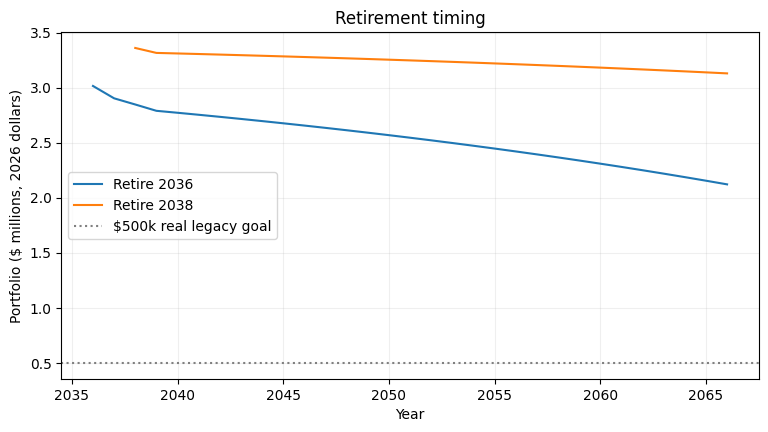

Trade-off: two more working years reduce the first-year portfolio withdrawal rate and increase the modeled 2066 balance.


In [2]:
timing = {'Retire 2036': frame(),
          'Retire 2038': frame(replace(a, retirement_age_a=67))}
show(timing)
plot(timing, 'Retirement timing')
print('Trade-off: two more working years reduce the first-year portfolio withdrawal rate and increase the modeled 2066 balance.')

## Decision 2 — Hold spending or make a temporary discretionary cut?

Both paths suffer the same illustrative 20% portfolio return in 2036. The flexible path cuts $25,000 a year in 2026 purchasing power during 2037–2039, reducing the $145,000 target to the stated $120,000 essential-spending floor for those years. Spending returns to the original target in 2040. This is a defined client choice, not an automatically optimized withdrawal rule. [Morningstar's retirement-income research](https://www.morningstar.com/content/cs-assets/v3/assets/blt9415ea4cc4157833/bltb73b87c5d0c70ead/The_State_of_Retirement_Income_2025.pdf) discusses flexible spending methods; these exact cut amounts are our case assumptions.

,Retire,First withdrawal rate,Lowest real portfolio,2066 real portfolio,First shortfall,Real spending cuts,Real care cost
Maintain $145k target,2036,5.8%,"$642,533","$642,533",None,$0,$0
Cut to $120k for 3 years,2036,5.8%,"$831,138","$831,138",None,"$75,000",$0


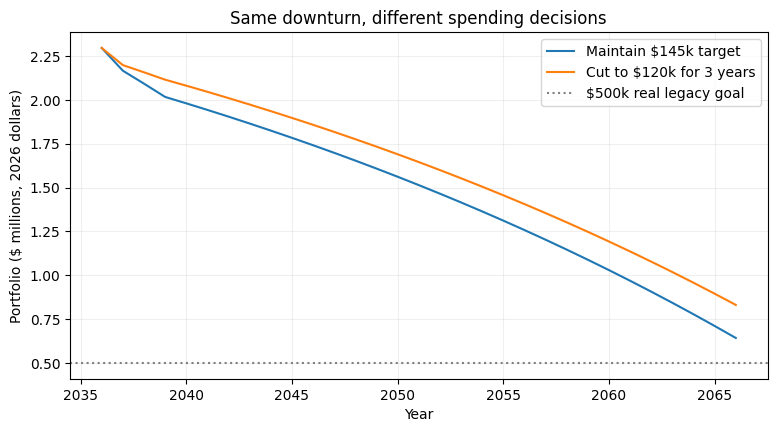

,year,spending,spending_cut,portfolio_withdrawal,ending
10,2036,"$185,612",$0,"$226,356","$2,940,173"
11,2037,"$157,450","$32,802","$192,013","$2,885,568"
12,2038,"$161,387","$33,622","$121,368","$2,902,410"
13,2039,"$165,421","$34,463","$124,402","$2,916,908"
14,2040,"$204,881",$0,"$115,450","$2,941,531"


In [3]:
flex_a = replace(a, discretionary_cut_today=25_000, cut_start_year=2037, cut_end_year=2039)
spending_cases = {'Maintain $145k target': frame(shock=True),
                  'Cut to $120k for 3 years': frame(flex_a, shock=True)}
show(spending_cases)
plot(spending_cases, 'Same downturn, different spending decisions')
display(spending_cases['Cut to $120k for 3 years'].loc[
    lambda x: x.year.between(2036, 2040),
    ['year','spending','spending_cut','portfolio_withdrawal','ending']]
    .style.format({'spending':'${:,.0f}','spending_cut':'${:,.0f}',
                   'portfolio_withdrawal':'${:,.0f}','ending':'${:,.0f}'}))

## Decision 3 — Claim Elena's benefit at 67 or 70?

Marco claims at 67 in both paths. Delaying Elena's modeled $46,000 age-67 benefit to 70 raises it by 24% to $57,040 in 2026 dollars under the [SSA delayed-credit schedule](https://www.ssa.gov/benefits/retirement/planner/delayret.html). The household must fund three more years without Elena's benefit. The second comparison adds the same 2051 survivor transition to both paths. The model uses the higher of the two benefits as a simplified survivor-income proxy; actual survivor rules and benefit statements require an SSA review.

In [4]:
claiming = {'Elena claims 67': frame(),
            'Elena claims 70': frame(replace(a, claim_age_a=70))}
show(claiming)
display(pd.DataFrame({
    name: data.loc[data.year.between(2038, 2043), 'social_security'].to_numpy() /
          data.loc[data.year.between(2038, 2043), 'price_index'].to_numpy()
    for name, data in claiming.items()}, index=range(2038, 2044)).style.format('${:,.0f}'))
survivor_claiming = {'Claim 67, survivor in 2051': frame(replace(a, survivor_year=2051)),
                    'Claim 70, survivor in 2051': frame(replace(a, claim_age_a=70, survivor_year=2051))}
show(survivor_claiming)

,Retire,First withdrawal rate,Lowest real portfolio,2066 real portfolio,First shortfall,Real spending cuts,Real care cost
Elena claims 67,2036,5.8%,"$2,121,461","$2,121,461",None,$0,$0
Elena claims 70,2036,5.8%,"$2,287,591","$2,287,591",None,$0,$0


,Elena claims 67,Elena claims 70
2038,"$46,000",$0
2039,"$46,000",$0
2040,"$78,000","$32,000"
2041,"$78,000","$89,040"
2042,"$78,000","$89,040"
2043,"$78,000","$89,040"


,Retire,First withdrawal rate,Lowest real portfolio,2066 real portfolio,First shortfall,Real spending cuts,Real care cost
"Claim 67, survivor in 2051",2036,5.8%,"$2,195,555","$2,195,555",None,$0,$0
"Claim 70, survivor in 2051",2036,5.8%,"$2,361,685","$2,361,685",None,$0,$0


## Decision 4 — Fund care and protect the surviving spouse

Assume an extra $90,000 per year in 2026 purchasing power for care during 2048–2050. Then Elena dies in 2051; Marco's household spending falls from $145,000 to an assumed $110,000 real annually, and Social Security falls from two benefits to a simplified higher-benefit survivor proxy. Separate care-only and survivor-only paths reveal how each assumption changes the result. The 18% portfolio-withdrawal tax reserve remains fixed, so this is **not** a widow tax or long-term-care insurance analysis.

,Retire,First withdrawal rate,Lowest real portfolio,2066 real portfolio,First shortfall,Real spending cuts,Real care cost
No life event,2036,5.8%,"$2,121,461","$2,121,461",None,$0,$0
Care only,2036,5.8%,"$1,600,584","$1,600,584",None,$0,"$270,000"
Survivor only,2036,5.8%,"$2,195,555","$2,195,555",None,$0,$0
Care then survivor,2036,5.8%,"$1,674,678","$1,674,678",None,$0,"$270,000"


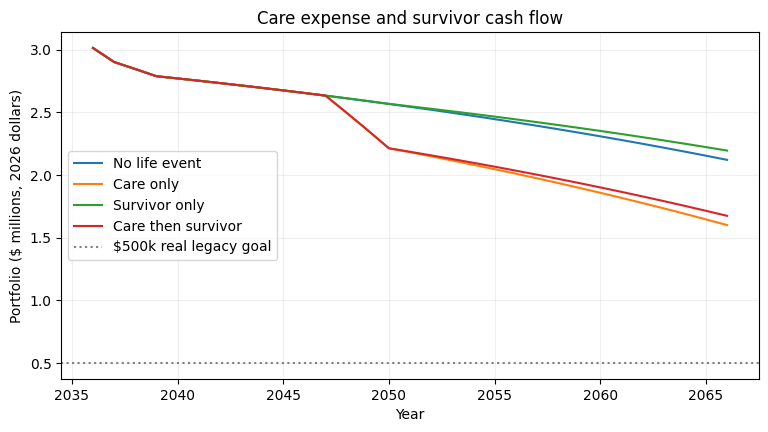

,year,spending,care_cost,social_security,portfolio_withdrawal,ending
21,2047,"$243,539",$0,"$131,007","$137,234","$4,424,539"
22,2048,"$404,569","$154,941","$134,283","$329,618","$4,299,667"
23,2049,"$414,684","$158,815","$137,640","$337,858","$4,159,899"
24,2050,"$425,051","$162,785","$141,081","$346,305","$4,004,274"
25,2051,"$203,934",$0,"$85,281","$144,698","$4,052,555"
26,2052,"$209,032",$0,"$87,413","$148,316","$4,099,451"
27,2053,"$214,258",$0,"$89,599","$152,023","$4,144,799"


In [5]:
care_a = replace(a, care_start_year=2048, care_years=3, care_cost_today=90_000)
survivor_a = replace(a, survivor_year=2051)
combined_a = replace(care_a, survivor_year=2051)
life_events = {'No life event': frame(), 'Care only': frame(care_a),
               'Survivor only': frame(survivor_a), 'Care then survivor': frame(combined_a)}
show(life_events)
plot(life_events, 'Care expense and survivor cash flow')
display(life_events['Care then survivor'].loc[
    lambda x: x.year.between(2047, 2053),
    ['year','spending','care_cost','social_security','portfolio_withdrawal','ending']]
    .style.format({'spending':'${:,.0f}','care_cost':'${:,.0f}',
                   'social_security':'${:,.0f}','portfolio_withdrawal':'${:,.0f}',
                   'ending':'${:,.0f}'}))

## Adviser recommendation and follow-up

1. Confirm the household's actual benefit statements, health costs, and essential-versus-discretionary budget. The 2038 retirement option materially reduces initial withdrawal pressure, but its lifestyle cost must be discussed.
2. Write a spending policy before retirement: identify the $25,000 of discretionary expenses that could be paused for three years. Agree on when the cut starts and ends; do not assume clients will accept it without discussion.
3. Compare Social Security claiming with individual life expectancy and survivor needs. Claiming at 70 raises the modeled benefit but requires more early portfolio cash.
4. Obtain long-term-care quotes and legal documents. The care and survivor costs are assumptions, while actual benefits, taxes, insurance, estate documents, and state law must be verified.
5. Recalculate annually. These deterministic paths omit return volatility beyond the stated shock, investment fees, tax-bracket interactions, Medicare premiums, RMDs, and changes in law. The 2066 balance is an illustration, not a guaranteed inheritance.

**Sources:** [SSA delayed credits](https://www.ssa.gov/benefits/retirement/planner/delayret.html), [SSA survivor-benefit overview](https://www.ssa.gov/benefits/retirement/planner/claiming.html), [Morningstar 2025 retirement-income research](https://www.morningstar.com/content/cs-assets/v3/assets/blt9415ea4cc4157833/bltb73b87c5d0c70ead/The_State_of_Retirement_Income_2025.pdf), [IRS beneficiary guidance](https://www.irs.gov/retirement-plans/plan-participant-employee/retirement-topics-beneficiary).